In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 2,
    'axes.labelsize': 22,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'cm',
    'figure.dpi': 100,
    'savefig.bbox': 'tight',
    
    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

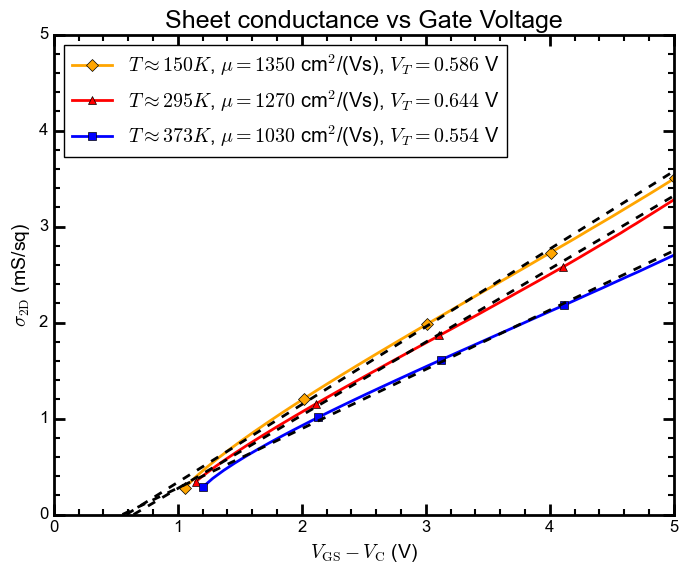

In [11]:
data1 = np.loadtxt("./Mobility/20262004004.dat")
data2 = np.loadtxt("./Data-20262805-gvdP/20262805005.dat")
data3 = np.loadtxt("./Data-20262805-gvdP/20262805014.dat")

datasets_gvdP = [
    ("150 K", data3, 'orange', 'D', 10, 1350, 0.586),
    ("295 K", data1, 'red', '^', 80, 1270, 0.644),
    ("373 K", data2, 'blue', 's', 10, 1030, 0.554),
]

for label, data, color, marker, markevery, mu_cm2_vs, V_T in datasets_gvdP:
    V_GS = data[:, 0]
    I_DS = data[:, 2]
    V_DS = data[:, 3]
    V_C = 0.5*(data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    plt.plot(
        V_GS - V_C,
        sigma*1e3,
        lw=2,
        label=rf"$T \approx {label}$, $\mu={mu_cm2_vs}$ cm$^2$/(Vs), $V_T={V_T:.3f}$ V",
        color=color,
        marker=marker,
        linestyle='-',
        markevery=markevery,
    )

C = 3e-12  # 3pF
W = 50e-6  # 50um
L = 10e-6  # 10um
Ci = C / (W * L)  # F/m^2

linear_lines = [
    ("150 K", 1350, 0.586),
    ("373 K", 1030, 0.554),
    ("295 K", 1270, 0.644),
]

for temp_label, mu_cm2_vs, V_T in linear_lines:
    x_line = np.linspace(V_T, 5, 200)
    sigma_line = Ci * (mu_cm2_vs / 1e4) * (x_line - V_T) * 1e3
    plt.plot(x_line, sigma_line, 'k--', lw=2)

plt.xlabel(r"$V_\text{GS} - V_\text{C}$ (V)", fontsize=14)
plt.ylabel(r"$\sigma_\text{2D}$ (mS/sq)", fontsize=14)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage", fontsize=18)
# plt.savefig("sheet_conductance_temp.eps", format='eps', bbox_inches='tight')
plt.show()


a = 0.000807 ± 4.16e-06
b = -0.000473 ± 1.8e-05
R^2 = 1 - 0.2
V_T = (0.586 ± 0.0225) V
mu_int = (1.35e+03 ± 6.93) cm^2/Vs


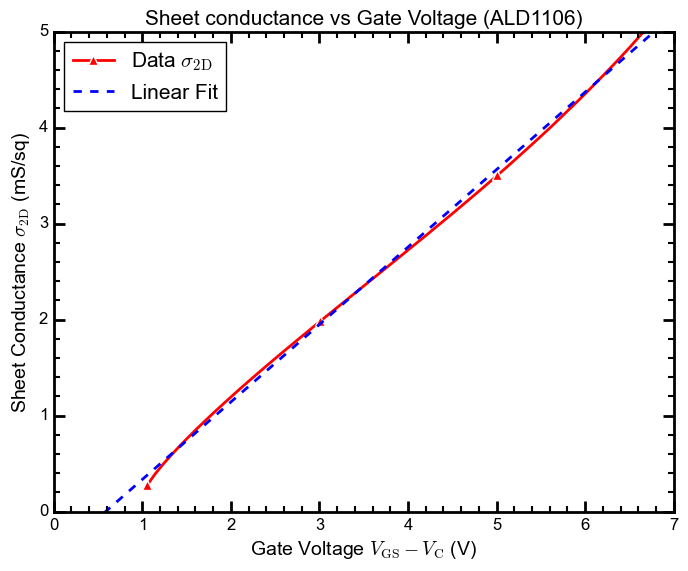

In [12]:
data = data3

V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_C = 0.5*(data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = data[:, 7]

C = 3e-12 # 3pF
W = 50e-6 # 50um
L = 10e-6 # 10um
Ci = C / (W * L) # F/m^2
V_del = (V_GS - V_C)

mask = (V_del > 1) & (V_del < 7) & (sigma > 0)
def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, V_del[mask], sigma[mask])
sigma_fit = func(V_del, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((sigma - sigma_fit) ** 2)
ss_tot = np.sum((sigma - np.mean(sigma)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
V_T_fit = -b / a
V_T_err = abs(V_T_fit) * np.sqrt((b_err / b) ** 2 + (a_err / a) ** 2)
mu_fit = a / Ci * 1e4
mu_err = abs(mu_fit * a_err / a)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = 1 - {1-r2:.1g}")

print(f"V_T = ({V_T_fit:.3g} ± {V_T_err:.3g}) V")
print(f"mu_int = ({mu_fit:.3g} ± {mu_err:.3g}) cm^2/Vs")



x = np.linspace(0, 7, 100)
plt.plot(V_GS - V_C, sigma*1e3, '^', label=r'Data $\sigma_\text{2D}$',lw=2,ls='-', color='red', markevery=20, markeredgecolor="white", markeredgewidth=1, markersize=7)
plt.plot(x, func(x, *popt)*1e3, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"Gate Voltage $V_\text{GS} - V_\text{C}$ (V)", fontsize=14)
plt.ylabel(r"Sheet Conductance $\sigma_\text{2D}$ (mS/sq)", fontsize=14)
plt.xlim(0, 7)
plt.ylim(0, 5)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=15)
plt.title(r"Sheet conductance vs Gate Voltage (ALD1106)", fontsize=15)
# plt.savefig("conductance_fit.eps", format='eps', bbox_inches='tight')
plt.show()

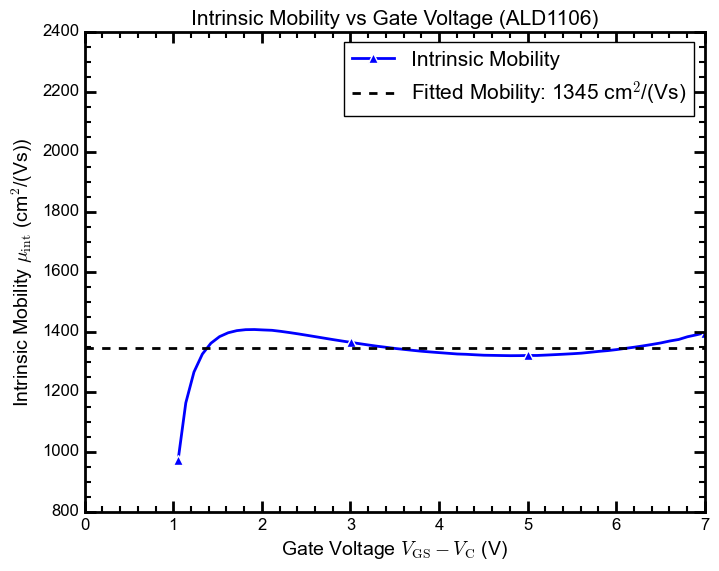

In [13]:
mu_int = sigma / (Ci * (V_GS - V_C - V_T_fit)) * 1e4

plt.plot(V_GS - V_C, mu_int, '^', label=r'Intrinsic Mobility', color='blue',lw=2, ls='-', markevery=20, markeredgecolor="white", markeredgewidth=1, markersize=7)
plt.plot(x, np.full_like(x, mu_fit), lw=2, label=rf'Fitted Mobility: {mu_fit:.0f} cm$^2$/(Vs)', color='k', linestyle='--')
plt.xlabel(r"Gate Voltage $V_\text{GS} - V_\text{C}$ (V)", fontsize=14)
plt.ylabel(r"Intrinsic Mobility $\mu_\text{int}$ (cm$^2$/(Vs))", fontsize=14)
plt.xlim(0, 7)
# plt.ylim(0, 2000)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=15)
plt.title(r"Intrinsic Mobility vs Gate Voltage (ALD1106)", fontsize=15)
# plt.savefig("mobility_fit.eps", format='eps', bbox_inches='tight')
plt.show()